# Student Info
## Name: Jia Changyu
## English Name: Iris
## ID: C00292876

# 1. Introduction

In [56]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import chess
import chess.pgn
from tqdm import tqdm
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import random

warnings.filterwarnings('ignore')

In [57]:
dataset_path = "../data/train.csv"
chessData = pd.read_csv(dataset_path)

# 2. Initial Exploration

In [58]:
print(f"size of Dataset: {len(chessData)} 行")
print(f"Columns: {chessData.columns.tolist()}")
print("\nNull value check:")
print(chessData.isnull().sum())


size of Dataset: 58785 行
Columns: ['id', 'board', 'black_score', 'best_move']

Null value check:
id             0
board          0
black_score    0
best_move      0
dtype: int64


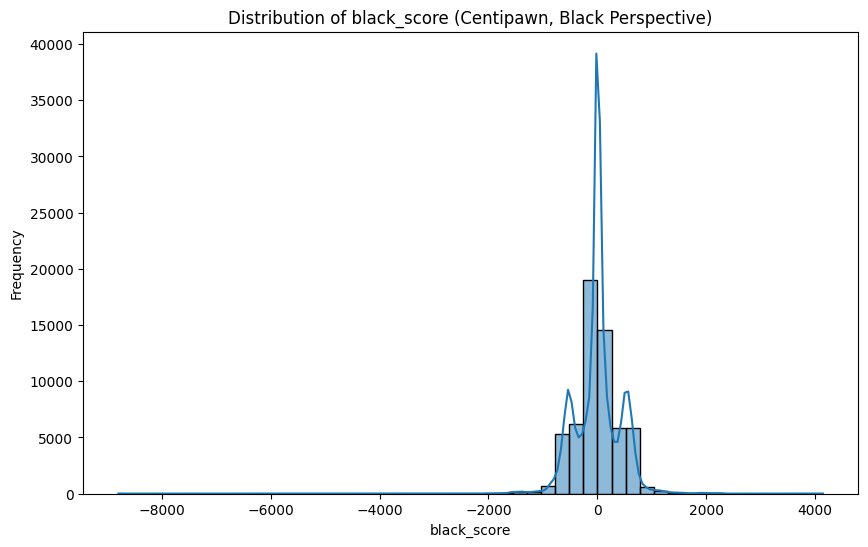

In [59]:
plt.figure(figsize=(10, 6))
sns.histplot(chessData['black_score'], bins=50, kde=True)
plt.title('Distribution of black_score (Centipawn, Black Perspective)')
plt.xlabel('black_score')
plt.ylabel('Frequency')
plt.show()

In [60]:
 # 最佳走法频率统计
move_counter = Counter(chessData['best_move'])
print("\nTop 10 most common best moves:")
for move, count in move_counter.most_common(10):
    print(f"  {move}: {count}  ({count/len(chessData)*100:.2f}%)")


Top 10 most common best moves:
  d4d5: 325  (0.55%)
  d4e5: 317  (0.54%)
  d2d4: 316  (0.54%)
  c4d5: 316  (0.54%)
  c5d4: 299  (0.51%)
  d5e4: 290  (0.49%)
  b8c6: 289  (0.49%)
  e7e5: 273  (0.46%)
  a5a4: 271  (0.46%)
  f5e4: 267  (0.45%)


In [61]:
sample = chessData.sample(1).iloc[0]
board = chess.Board(sample['board'])
print("\nRandom sample board:")
print(board)
print(f"FEN: {sample['board']}")
print(f"Black score (centipawn): {sample['black_score']}")
print(f"Best move: {sample['best_move']}")


Random sample board:
. . . . r . k .
. R . . . p . .
p . . . . . p p
R . . . . r . .
. . . . . . . .
. . . . . . . P
. . . . . P P .
. . . . . . K .
FEN: 4r1k1/1R3p2/p5pp/R4r2/8/7P/5PP1/6K1 b - - 0 34
Black score (centipawn): 594.0
Best move: f5a5


In [62]:
# -------------------- 棋盘编码函数 --------------------
def fen_to_tensor(fen: str) -> torch.Tensor:
    board = chess.Board(fen)
    tensor = np.zeros((12, 8, 8), dtype=np.float32)
    piece_to_channel = {
        chess.PAWN: 0, chess.KNIGHT: 1, chess.BISHOP: 2,
        chess.ROOK: 3, chess.QUEEN: 4, chess.KING: 5
    }
    for square in chess.SQUARES:
        piece = board.piece_at(square)
        if piece is not None:
            row = square // 8
            col = square % 8
            channel = piece_to_channel[piece.piece_type]
            if piece.color == chess.BLACK:
                channel += 6
            tensor[channel, row, col] = 1.0
    return torch.tensor(tensor, dtype=torch.float32)

In [63]:
# -------------------- 数据集类 --------------------
class ChessValueDataset(Dataset):
    def __init__(self, csv_path):
        chessData = pd.read_csv(csv_path)
        chessData['white_score'] = -chessData['black_score']
        self.fens = chessData['board'].values
        self.scores = chessData['white_score'].values.astype(np.float32)
        
        # 对分数进行归一化
        self.score_mean = np.mean(self.scores)
        self.score_std = np.std(self.scores)
        if self.score_std > 0:
            self.scores = (self.scores - self.score_mean) / self.score_std
        else:
            self.scores = self.scores - self.score_mean
        
        print(f"数据集统计: 样本数={len(self.fens)}, 平均分={self.score_mean:.2f}, 标准差={self.score_std:.2f}")
    def __len__(self):
        return len(self.fens)
    
    def __getitem__(self, idx):
        x = fen_to_tensor(self.fens[idx])
        y = torch.tensor(self.scores[idx], dtype=torch.float32)
        return x, y

In [64]:
# -------------------- 价值网络定义 --------------------
class ChessValueNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(12, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2),  # 8x8 -> 3x3 (因为(8-3)/2+1=3.5向下取整=3)
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((3, 3))  # 确保输出固定为3x3
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),  # 修正为128 * 3 * 3=1152
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )
    
    def forward(self, x):
        x = self.conv_block(x)
        value = self.fc(x)
        return value

In [65]:
# ==================== 设备配置 ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")


使用设备: cpu


In [66]:
# ==================== 训练模型 ====================
print("load the training dataset...")
dataset = ChessValueDataset(dataset_path)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

model = ChessValueNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
criterion = nn.MSELoss()

print("start training the value network...")
model.train()
epochs = 10
for epoch in range(epochs):
    total_loss = 0.0
    progress_bar = tqdm(dataloader, desc=f'Epoch {epoch+1}/{epochs}')
    for batch_x, batch_y in progress_bar:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        pred = model(batch_x).squeeze()
        loss = criterion(pred, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(batch_x)
        progress_bar.set_postfix({'loss': loss.item()})
    avg_loss = total_loss / len(dataset)
    scheduler.step()
    print(f'Epoch {epoch+1} finished, average loss: {avg_loss:.4f}')


load the training dataset...
数据集统计: 样本数=58785, 平均分=-8.13, 标准差=404.70
start training the value network...


Epoch 1/15:   0%|          | 0/1838 [00:00<?, ?it/s]

Epoch 1/15: 100%|██████████| 1838/1838 [00:19<00:00, 94.11it/s, loss=0.0075]


Epoch 1 finished, average loss: 0.6769


Epoch 2/15: 100%|██████████| 1838/1838 [00:25<00:00, 72.04it/s, loss=0.00357]


...

Epoch 3/15: 100%|██████████| 1838/1838 [00:28<00:00, 63.96it/s, loss=0.214] 


Epoch 3 finished, average loss: 0.3685


Epoch 4/15: 100%|██████████| 1838/1838 [00:29<00:00, 63.17it/s, loss=0.92]  


Epoch 4 finished, average loss: 0.3206


Epoch 5/15:  22%|██▏       | 404/1838 [00:06<00:22, 63.90it/s, loss=0.292] 